In [128]:
import numpy as np
from skimage import io
import tifffile as tiff
import anndata as ad
import matplotlib.pyplot as plt
import os

In [132]:
SOURCE_DIR = '/mnt/data/lorenzo/VSC_DATA/Jelle/LG002'
ALIGNED_MSI_IMAGE_PATH = os.path.join(SOURCE_DIR, "alignment/msi/resulting_image.tiff")
LARGE_XENIUM_IMAGE_PATH = os.path.join(SOURCE_DIR, "misc/large_xenium_lg002.tiff")
SMALL_XENIUM_IMAGE_PATH = os.path.join(SOURCE_DIR, "xenium/xenium_lg002.tiff")
ORIGINAL_MSI_IMAGE_PATH = os.path.join(SOURCE_DIR, "msi/msi_image_lg002.tiff")

XENIUM_ANNDATA_FILE = os.path.join(SOURCE_DIR, "xenium/xenium_david_2.h5ad")
CELL_LOCATION_OBS = ["center_row", "center_col"]

In [130]:
def find_aligned_image_corners(aligned_image: np.ndarray) -> np.ndarray | None:
    """
    Given an aligned image that contains a quadrilateral non-negative sub-matrix, representing the aligned
    image, and a negative padding around it, this method finds the corners of the quadrilateral.

    Parameters:
    ------------
    aligned_image (np.ndarray): 
        The aligned image with a quadrilateral object and negative padding.
    
    Returns:
    ------------
    np.ndarray:
        An array of shape (4, 2) containing the coordinates of the corners in the order:
        [Top-Left, Top-Right, Bottom-Right, Bottom-Left].
        Returns None if no quadrilateral corners are found.
    """
    # Create binary mask (object = True, background = False)
    mask = aligned_image >= 0
    if not np.any(mask):
        return None  # No object found
    
    # Find boundary points (points adjacent to background)
    padded = np.pad(mask, 1, mode='constant', constant_values=False)
    is_boundary = (
        (padded[1:-1, 1:-1] != padded[:-2, 1:-1]) |  # Check top neighbor
        (padded[1:-1, 1:-1] != padded[2:, 1:-1])   |  # Check bottom neighbor
        (padded[1:-1, 1:-1] != padded[1:-1, :-2])  |  # Check left neighbor
        (padded[1:-1, 1:-1] != padded[1:-1, 2:])      # Check right neighbor
    )
    boundary_coords = np.argwhere(is_boundary)
    
    # Extract x and y coordinates (x = column, y = row)
    x = boundary_coords[:, 1]
    y = boundary_coords[:, 0]
    
    # Find corner indices using vector direction analysis
    idx_tl = np.argmax(-x - y)  # Top-left: max(-x - y)
    idx_tr = np.argmax(x - y)    # Top-right: max(x - y)
    idx_br = np.argmax(x + y)    # Bottom-right: max(x + y)
    idx_bl = np.argmax(-x + y)   # Bottom-left: max(-x + y)
    
    # Extract corners in order [TL, TR, BR, BL]
    corners = np.array([
        [x[idx_tl], y[idx_tl]],  # Top-left
        [x[idx_tr], y[idx_tr]],  # Top-right
        [x[idx_br], y[idx_br]],  # Bottom-right
        [x[idx_bl], y[idx_bl]]   # Bottom-left
    ])
    
    return corners

def get_coordinate_converter(corners_source_space: np.ndarray, corners_target_space: np.ndarray) -> callable:
    """
    Returns a function that converts a point (x, y) in the source space into a point (x', y') in the target space.
    To compute the conversion, it uses a least-squares solution to find the affine transformation
    that maps four landmarks points from the source space to the target space.

    For this to work, we assume that the source and the target spaces are finite spaces defined by four corners
    (an image, for example).
    
    Parameters:
    -----------
    corners_source_space : np.ndarray
        An array of shape (4, 2) containing the coordinates of the corners in the source space.
        The order of the corners should be: [Top-Left, Top-Right, Bottom-Right, Bottom-Left].
    corners_target_space : np.ndarray
        An array of shape (4, 2) containing the coordinates of the corners in the target space.
        The order of the corners should be: [Top-Left, Top-Right, Bottom-Right, Bottom-Left].
    
    Returns:
    --------
    callable
        A function that takes two float arguments (x, y) representing a point in the source space
        and returns a tuple (x', y') representing the corresponding point in the target space.
        The returned coordinates are rounded to three decimal places.
    """

    # Prepare matrices for least-squares solution
    A = np.hstack([corners_source_space, np.ones((4, 1))])  # Add homogeneous coordinate
    B = corners_target_space
    
    # Solve for affine parameters (3x2 matrix)
    params, _, _, _ = np.linalg.lstsq(A, B, rcond=None)
    
    # Construct 3x3 affine matrix M
    M = np.vstack([params.T, [0, 0, 1]])
    
    # Compute inverse matrix for reverse mapping
    M_inv = np.linalg.inv(M)
    
    def convert_big_to_small(x, y):
        # Convert point to homogeneous coordinates
        point_big = np.array([x, y, 1])
        # Apply inverse transformation
        point_small = M_inv @ point_big
        return round(point_small[0] + 1e-8, 3), round(point_small[1] + 1e-8, 3)
    
    return convert_big_to_small



def map_xenium_to_msi(xenium_coord: tuple[int, int], xenium_size: np.ndarray[np.int32], small_xenium_size: np.ndarray[np.int32], msi_size: np.ndarray[np.int32], msi_corners_small_xenium, flip_y: bool = True):
    """
    Map a Xenium coordinate from the original image to the corresponding MSI coordinate.

    Parameters:
    -----------
    xenium_coord : tuple[int, int]
        Coordinate in the Xenium image.
    original_xenium_size : tuple[int, int]
        Size of the original Xenium image (width, height).
    small_xenium_size : tuple[int, int]
        Size of the small Xenium image (width, height).
    original_msi_size : tuple[int, int]
        Size of the original MSI image (width, height).
    origin_offset : tuple[int, int] 
        Offset to adjust the origin of the Xenium coordinate.
    flip_y : bool, optional
        Whether to flip the y-coordinate (default is True).

    Returns:
    --------
    tuple[float, float] or (None, None)
        Mapped MSI coordinate (x', y') as float, or (None, None)
        if the coordinate is out of bounds.
    """

    xenium_corners = np.array([
        (0, 0),  # Bottom-left corner
        (xenium_size[0], 0),  # Bottom-right corner
        (xenium_size[0], xenium_size[1]),  # Top-right corner
        (0, xenium_size[1])  # Top-left corner
    ], dtype=np.float32)

    small_xenium_corners = np.array([
        (0, 0),  # Bottom-left corner
        (small_xenium_size[0], 0),  # Bottom-right corner
        (small_xenium_size[0], small_xenium_size[1]),  # Top-right corner
        (0, small_xenium_size[1])  # Top-left corner
    ], dtype=np.float32)

    msi_corners = np.array([
        (0, 0),            # Bottom-left corner
        (msi_size[0], 0),  # Bottom-right corner
        (msi_size[0], msi_size[1]),  # Top-right corner
        (0, msi_size[1])   # Top-left corner
    ], dtype=np.float32)

    xenium_to_small_xenium = get_coordinate_converter(small_xenium_corners, xenium_corners)
    small_xenium_to_msi = get_coordinate_converter(msi_corners, msi_corners_small_xenium)


    # Convert the Xenium coordinate to small Xenium coordinate
    small_xenium_coord = xenium_to_small_xenium(xenium_coord[0], xenium_coord[1])

    # Convert the small Xenium coordinate to MSI coordinate
    msi_coord = small_xenium_to_msi(small_xenium_coord[0], small_xenium_coord[1])

    # Flip the y-coordinate if specified
    if flip_y:
        msi_coord = (msi_size[0] - msi_coord[0], msi_coord[1])

    # Filter out-of-bounds coordinates
    if (msi_coord[0] < 0 or msi_coord[0] >= msi_size[0] or
        msi_coord[1] < 0 or msi_coord[1] >= msi_size[1]):
        return np.nan, np.nan
    
    return np.array(msi_coord)

## Load Xenium AnnData file
Use this file to obtain the centroid of each identified cell location. With this centroid, create two TIFF images, one with the original size and one with smaller and more managable sizes

In [133]:
# Load Xenium AnnData
xenium_adata = ad.read_h5ad(XENIUM_ANNDATA_FILE)

In [134]:
# Compute the TIFF image size based on the space required by the Xenium coordinates
original_coords = np.array([xenium_adata.obs[CELL_LOCATION_OBS[0]], xenium_adata.obs[CELL_LOCATION_OBS[1]]]).T
reduced_coords = original_coords // 4

original_size = (np.max(original_coords[:, 0]) + 1, np.max(original_coords[:, 1]) + 1)
reduced_size = (np.max(reduced_coords[:, 0]) + 1, np.max(reduced_coords[:, 1]) + 1)

In [136]:
from PIL import Image, ImageDraw

original_img = Image.new('L', original_size, 0)
reduced_img = Image.new('L', reduced_size, 0)
original_draw = ImageDraw.Draw(original_img)
reduced_draw = ImageDraw.Draw(reduced_img)

# Define circle parameters
radius = 30

# Draw solid circles
for (x, y) in original_coords:
    bbox = [x - radius, y - radius, x + radius, y + radius]
    original_draw.ellipse(bbox, fill=1)

for (x, y) in reduced_coords:
    bbox = [x - radius, y - radius, x + radius, y + radius]
    reduced_draw.ellipse(bbox, fill=1)

# Same the images
tiff.imwrite(LARGE_XENIUM_IMAGE_PATH, original_img, compression='zlib')
tiff.imwrite(SMALL_XENIUM_IMAGE_PATH, reduced_img, compression='zlib')

## Load MSI and Xenium after FOCUS alignment
Before performing this step you need to align MSI and Xenium using FOCUS

In [137]:
# Load the aligned MSI image to obtain the landmarks for the coordinate conversion
aligned_msi_image = io.imread(ALIGNED_MSI_IMAGE_PATH).sum(axis=-1)

In [138]:
# Load the original Xenium and MSI files to obtain the reference frames' sizes
XENIUM_SIZE, SMALL_XENIUM_SIZE, MSI_SIZE = None, None, None

with tiff.TiffFile(LARGE_XENIUM_IMAGE_PATH) as tif:
    XENIUM_SIZE = (tif.pages[0].shape[1], tif.pages[0].shape[0])

with tiff.TiffFile(ORIGINAL_MSI_IMAGE_PATH) as tif:
    MSI_SIZE = (tif.pages[0].shape[1], tif.pages[0].shape[0])

with tiff.TiffFile(SMALL_XENIUM_IMAGE_PATH) as tif:
    SMALL_XENIUM_SIZE = (tif.pages[0].shape[1], tif.pages[0].shape[0])

print("Original MSI Size: ", MSI_SIZE)
print("Original Xenium Size: ", XENIUM_SIZE)
print("Small Xenium Size: ", SMALL_XENIUM_SIZE)

Original MSI Size:  (746, 355)
Original Xenium Size:  (112515, 54680)
Small Xenium Size:  (28129, 13670)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


(np.float64(-0.5), np.float64(28128.5), np.float64(13669.5), np.float64(-0.5))

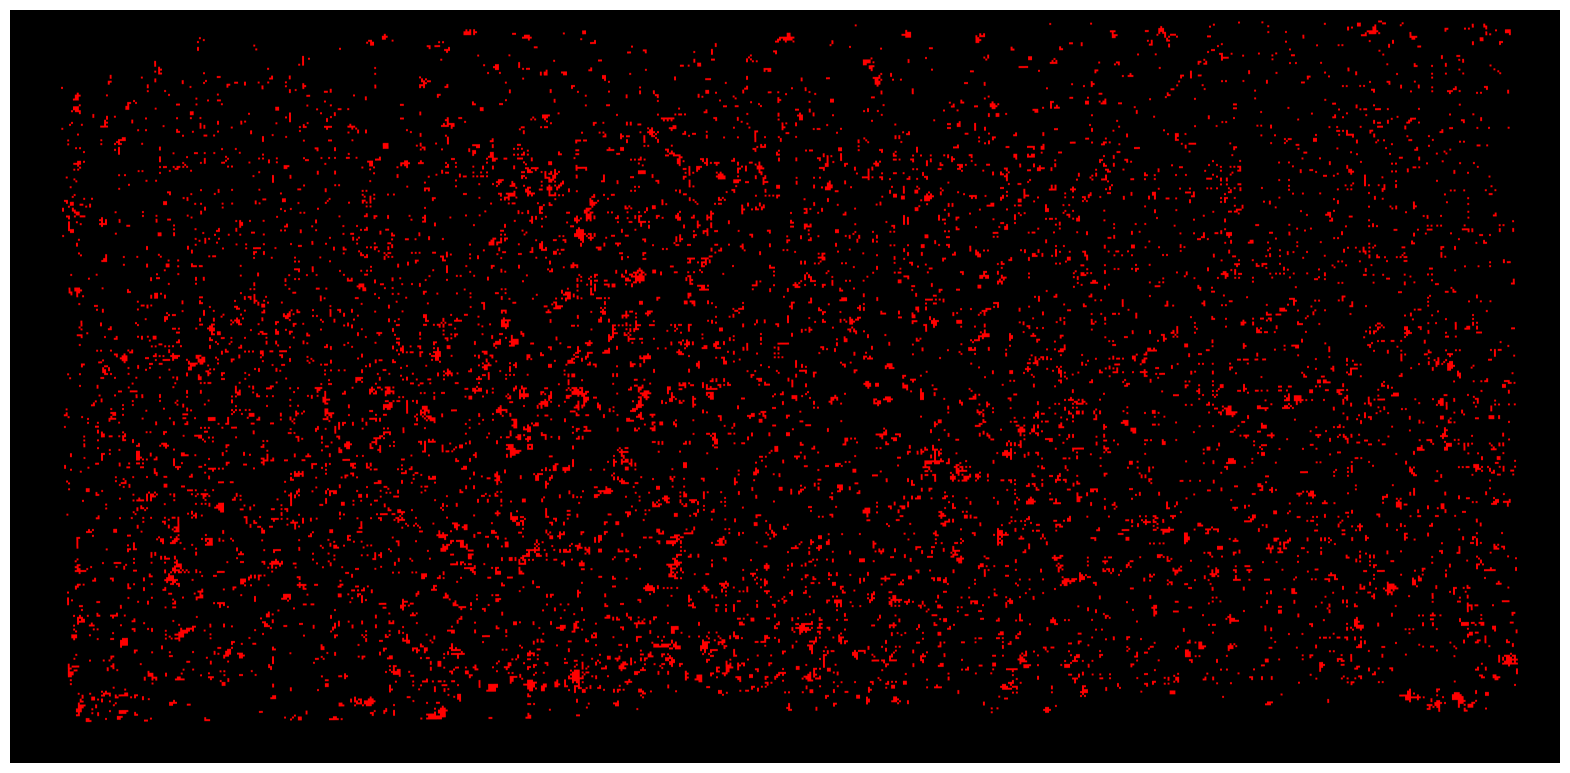

In [139]:
img = io.imread(ALIGNED_MSI_IMAGE_PATH)
plt.figure(figsize=(20, 20))
plt.imshow(img)
plt.axis('off')

In [140]:
# Load the cell location dataframe
cell_positions = ad.read_h5ad(XENIUM_ANNDATA_FILE)

# Obtain the coordinates of each cell detected in Xenium, scaled by the SCALING_FACTOR
coordinates = np.array([xenium_adata.obs["center_row"], xenium_adata.obs["center_col"]]).T

In [141]:
# Scan the aligned image to find the corners of the quadrilateral (reference points to compute the coordinates transformation)
MSI_CORNERS_IN_SMALL_XENIUM = find_aligned_image_corners(aligned_msi_image)

In [142]:
# Conver the Xenium cell coordinates to MSI coordinates
converted_coordinates = np.array([map_xenium_to_msi(coord, XENIUM_SIZE, SMALL_XENIUM_SIZE, MSI_SIZE, MSI_CORNERS_IN_SMALL_XENIUM, flip_y=True) for coord in coordinates])

In [143]:
# Add the converted coordinates to the cell positions DataFrame
cell_positions.obs['x_msi'] = converted_coordinates[:, 0]
cell_positions.obs['y_msi'] = converted_coordinates[:, 1]

In [144]:
# Save the converted coordinates to a AnnData file
cell_positions.write(XENIUM_ANNDATA_FILE)

In [145]:
# Fake data to simulate the MSI matrix (with it's original 2D shape)
fake_maldi_matrix = np.random.rand(MSI_SIZE[0], MSI_SIZE[1]) * 1000
print("Fake MALDI Matrix Shape: ", fake_maldi_matrix.shape)
print("Fake MALDI Matrix Sample: ", fake_maldi_matrix[0, 0:10])

# Get the (x, y) MSI coordinates that were generated from Xenium (TSV file) and convert them into a 2D array with shape (N, 2)
cell_position_msi = np.array([cell_positions.obs['x_msi'].values, cell_positions.obs['y_msi'].values]).transpose(1, 0)
cell_position_msi = cell_position_msi[~np.isnan(cell_position_msi).any(axis=1)]
print("Converted coordinates shape: ", cell_position_msi.shape)
print("Converted coordinates: ", cell_position_msi[0])

# Create a neighborhood matrix to store both the coordinates of each MSI pixel in the neighborhood of a cell and the corresponding intensities from the MSI matrix.
cell_neighborhood = np.zeros((cell_position_msi.shape[0], 4, 2), dtype=np.int32)
cell_neighborhood_intensities = np.zeros((cell_position_msi.shape[0], 4), dtype=np.float32)

for i, (x, y) in enumerate(cell_position_msi):
    x, y = np.floor(x).astype(np.int32), np.floor(y).astype(np.int32)
    cell_neighborhood[i] = np.array([
        [x, y],         # MSI Pixel in which the cell is located
        [x + 1, y],     # Left pixel
        [x, y + 1],     # Bottom pixel
        [x + 1, y + 1]  # Bottom-left diagonal pixel
    ])

    # Fill the neighborhood intensities matrix 
    cell_neighborhood_intensities[i] = np.zeros(4, dtype=np.float32)
    cell_neighborhood_intensities[i, 0] = fake_maldi_matrix[x, y]

    if 0 <= x + 1 < MSI_SIZE[0] and 0 <= y < MSI_SIZE[1]:
        cell_neighborhood_intensities[i, 1] = fake_maldi_matrix[x + 1, y]

    if 0 <= x < MSI_SIZE[0] and 0 <= y + 1 < MSI_SIZE[1]:
        cell_neighborhood_intensities[i, 2] = fake_maldi_matrix[x, y + 1]

    if 0 <= x + 1 < MSI_SIZE[0] and 0 <= y + 1 < MSI_SIZE[1]:
        cell_neighborhood_intensities[i, 3] = fake_maldi_matrix[x + 1, y + 1]
    

print("Cell neighborhood shape: ", cell_neighborhood.shape)
print("Cell neighborhood example: ", cell_neighborhood[0])

print("Cell neighborhood intensities shape: ", cell_neighborhood_intensities.shape)
print("Cell neighborhood intensities example: ", cell_neighborhood_intensities[0])

# For each cell, compute the Eucledian distance between its position and the center of each pixel in the neighborhood
cell_neighborhood_distances = np.linalg.norm(cell_neighborhood - cell_position_msi[:, np.newaxis, :], axis=-1)
print("Cell neighborhood distances shape: ", cell_neighborhood_distances.shape)
print("Cell neighborhood distances: ", cell_neighborhood_distances[0])

# Using the distances compute a scaling factor for the interpolation of MSI intensities.
scaling_factors = (1 / cell_neighborhood_distances) / np.sum(1 / cell_neighborhood_distances, axis=1, keepdims=True)
print("Scaling factors shape: ", scaling_factors.shape)
print("Scaling factors: ", scaling_factors[0])

# Interpolate intensities for each cell (weighing the intensities by the scaling factors)
msi_intensities_per_cell = np.nansum(cell_neighborhood_intensities * scaling_factors, axis=1)
print("MSI intensities per cell shape: ", msi_intensities_per_cell.shape)
print("MSI intensities per cell: ", msi_intensities_per_cell[0])

# Now msi_intensities_per_cell is an array with shape (N, ) that represents the MSI profile for each Xenium cell
# Note that only the cells that mapped inside the MSI file are included because of the filter applied to the first step
# Also note that if a cell is on the edge pixels (last row or last column) the MSI profile incorporate a padding that I defined
# arbitrarily (see neighborhood matrix above). The logic can be different.

Fake MALDI Matrix Shape:  (746, 355)
Fake MALDI Matrix Sample:  [509.42670975 948.71662072 683.92925531 630.18894089 212.79340001
 248.5379607  354.17955535  96.91725995 750.74130884 425.28711274]
Converted coordinates shape:  (13238, 2)
Converted coordinates:  [745.446  92.866]
Cell neighborhood shape:  (13238, 4, 2)
Cell neighborhood example:  [[745  92]
 [746  92]
 [745  93]
 [746  93]]
Cell neighborhood intensities shape:  (13238, 4)
Cell neighborhood intensities example:  [911.7761    0.      432.27933   0.     ]
Cell neighborhood distances shape:  (13238, 4)
Cell neighborhood distances:  [0.97410061 1.0280428  0.46569518 0.56997544]
Scaling factors shape:  (13238, 4)
Scaling factors:  [0.17396556 0.16483745 0.363886   0.29731098]
MSI intensities per cell shape:  (13238,)
MSI intensities per cell:  315.91804029168964
